In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./gene_expression.csv")

In [3]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


<Axes: xlabel='Gene One', ylabel='Gene Two'>

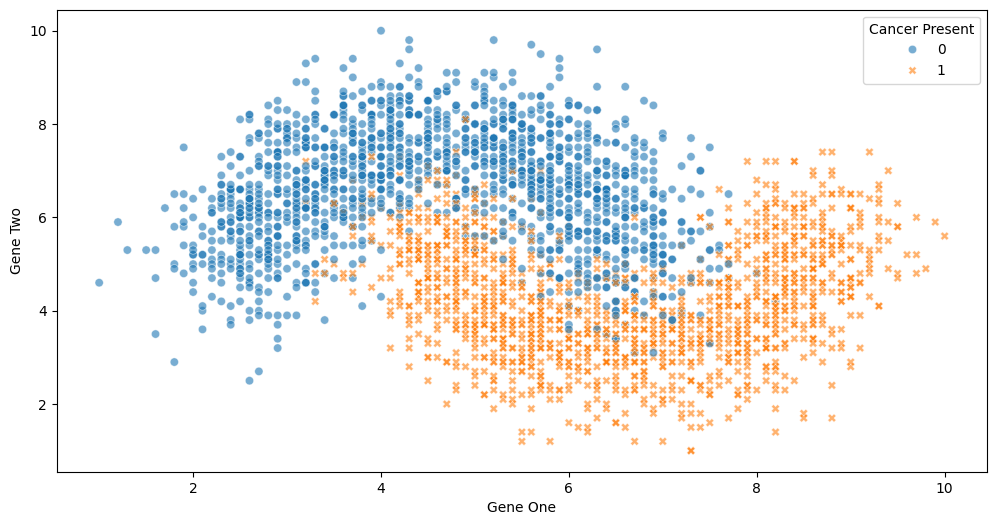

In [4]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df,x='Gene One',y='Gene Two',hue="Cancer Present",alpha=0.6,
               style='Cancer Present')
# plt.xlim(2,6)
# plt.ylim(4,8)

In [5]:
len(df)

3000

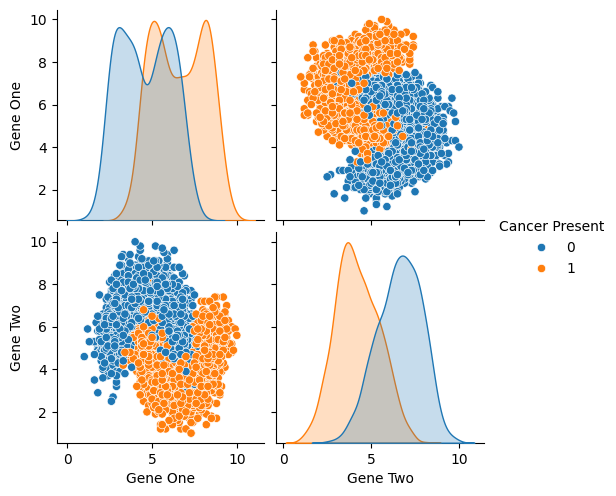

In [6]:
sns.pairplot(data=df,hue='Cancer Present')

## Machine Learning

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
from sklearn.preprocessing import StandardScaler

In [10]:
X = df.drop('Cancer Present',axis=1)

In [11]:
y = df['Cancer Present']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
scaler = StandardScaler()

In [14]:
scaled_X_train = scaler.fit_transform(X_train)

In [15]:
scaled_X_test = scaler.transform(X_test)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [18]:
# help(KNeighborsClassifier)

In [19]:
knn = KNeighborsClassifier(n_neighbors=1)

In [20]:
knn.fit(scaled_X_train,y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
y_pred = knn.predict(scaled_X_test)

In [22]:
from sklearn.metrics import confusion_matrix,classification_report

In [23]:
confusion_matrix(y_test,y_pred)

array([[422,  48],
       [ 50, 380]])

In [24]:
len(y_test)

900

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       470
           1       0.89      0.88      0.89       430

    accuracy                           0.89       900
   macro avg       0.89      0.89      0.89       900
weighted avg       0.89      0.89      0.89       900



In [27]:
df['Cancer Present'].value_counts()

Cancer Present
1    1500
0    1500
Name: count, dtype: int64